# NB05 — H2: Carbon-cycling KO enrichment under warming

Plus a clean H1 sensitivity check using direct (non-incubated) samples only.

**H2**: Carbon-degradation KOs (CAZymes, peptidases, TCA, β-oxidation, aromatic catabolism, methane, C1) are enriched in heated metatranscriptomes compared to controls, reflecting the published Barre Woods finding of accelerated respiration.

**Approach**:
1. Load the curated 60-KO C-cycling list from `user_data/c_cycling_kos.tsv`.
2. Per-KO heated-vs-control t-test (Welch) on log relative abundance, separately for DNA and RNA pools, stratified by horizon and overall.
3. Test enrichment of C-cycling KOs vs all KOs in the heated-up direction (Fisher's exact).
4. Volcano plot.
5. **H1 sensitivity** — re-run NB04's PERMANOVA on direct-sampled subsets only (no incubated).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import ttest_ind, false_discovery_control, fisher_exact

DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
USER_DIR = os.path.abspath('../user_data')

design = pd.read_csv(os.path.join(DATA_DIR, 'sample_design.tsv'), sep='\t')
ko = pd.read_csv(os.path.join(DATA_DIR, 'ko_counts_by_sample.tsv.gz'), sep='\t')
c_kos = pd.read_csv(os.path.join(USER_DIR, 'c_cycling_kos.tsv'), sep='\t')
print(f'Curated C-cycling KOs: {len(c_kos)}')
print(c_kos['category'].value_counts())

Curated C-cycling KOs: 62
category
cazyme            15
tca               15
methane            8
peptidase          7
aromatic           7
beta_oxidation     6
c1                 4
Name: count, dtype: int64


In [2]:
def build_kotable(ko_df, src):
    sub = ko_df[ko_df['source'] == src]
    mat = sub.pivot_table(index='biosample_id', columns='ko',
                          values='gene_count', aggfunc='sum', fill_value=0)
    rab = mat.div(mat.sum(axis=1), axis=0)
    return mat, rab

_, dna_rab = build_kotable(ko, 'DNA')
_, rna_rab = build_kotable(ko, 'RNA')
design_idx = design.set_index('biosample_id')
print(f'DNA: {dna_rab.shape}, RNA: {rna_rab.shape}')

DNA: (28, 12863), RNA: (39, 14302)


## 1. Per-KO heated-vs-control test (DNA and RNA)

Welch t-test on log10 relative abundance (with pseudo-count 1e-6).
Stratify by horizon to give two parallel views (organic and mineral).

In [3]:
def per_ko_de(M, meta_idx, horizon=None, min_samples=3):
    """M is samples x KO relative abundance. Returns DataFrame with t, p, log2_fc per KO."""
    samples = list(M.index)
    meta_sub = meta_idx.loc[samples]
    if horizon is not None:
        keep = meta_sub.index[meta_sub['horizon'] == horizon]
        M = M.loc[keep]
        meta_sub = meta_sub.loc[keep]
    if len(M) == 0:
        return pd.DataFrame()
    log = np.log10(M.values + 1e-6)
    treats = meta_sub['treatment'].values
    c_idx = np.where(treats == 'control')[0]
    h_idx = np.where(treats == 'heated')[0]
    if len(c_idx) < min_samples or len(h_idx) < min_samples:
        return pd.DataFrame()
    log_c = log[c_idx]
    log_h = log[h_idx]
    t, p = ttest_ind(log_h, log_c, equal_var=False, axis=0, nan_policy='omit')
    mean_c = M.values[c_idx].mean(axis=0)
    mean_h = M.values[h_idx].mean(axis=0)
    log2_fc = np.log2((mean_h + 1e-9) / (mean_c + 1e-9))
    df = pd.DataFrame({
        'ko': M.columns,
        'mean_control': mean_c,
        'mean_heated': mean_h,
        'log2_fc': log2_fc,
        't': t,
        'p': p,
        'n_control': len(c_idx),
        'n_heated': len(h_idx),
    })
    # FDR over the testable rows (drop NaN p)
    mask = df['p'].notna()
    q = np.full(len(df), np.nan)
    if mask.sum() > 0:
        q[mask.values] = false_discovery_control(df.loc[mask, 'p'].values, method='bh')
    df['q'] = q
    return df

# Compute DA per pool x horizon
da_results = []
for pool, M in [('DNA', dna_rab), ('RNA', rna_rab)]:
    for hz in ['organic', 'mineral']:
        res = per_ko_de(M, design_idx, horizon=hz)
        if len(res):
            res['pool'] = pool
            res['horizon'] = hz
            da_results.append(res)
DA = pd.concat(da_results, ignore_index=True)
print(f'DA rows: {len(DA):,}')
print(DA.groupby(['pool', 'horizon']).size())

DA rows: 54,330
pool  horizon
DNA   mineral    12863
      organic    12863
RNA   mineral    14302
      organic    14302
dtype: int64


/opt/conda/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/opt/conda/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/opt/conda/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)
/opt/conda/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:635: RuntimeWarning: P

## 2. C-cycling KO enrichment in heated-up hits (Fisher's exact)

For each (pool × horizon), build a 2×2 contingency: {C-cycling KO, other KO} × {heated-up hit, not heated-up}.
Define heated-up hit as `log2_fc > 0` AND `q < 0.10`.

In [4]:
c_set = set(c_kos['ko'])
rows = []
for (pool, hz), sub in DA.groupby(['pool', 'horizon']):
    sub = sub.copy()
    sub['is_c'] = sub['ko'].isin(c_set)
    sub['is_hit'] = (sub['log2_fc'] > 0) & (sub['q'] < 0.10)
    n_c_hit  = int(((sub['is_c']) & (sub['is_hit'])).sum())
    n_c_no   = int(((sub['is_c']) & (~sub['is_hit'])).sum())
    n_o_hit  = int(((~sub['is_c']) & (sub['is_hit'])).sum())
    n_o_no   = int(((~sub['is_c']) & (~sub['is_hit'])).sum())
    table = [[n_c_hit, n_c_no], [n_o_hit, n_o_no]]
    OR, p = fisher_exact(table, alternative='greater')
    rows.append({
        'pool': pool, 'horizon': hz,
        'n_c_hit': n_c_hit, 'n_c_total': n_c_hit + n_c_no,
        'n_other_hit': n_o_hit, 'n_other_total': n_o_hit + n_o_no,
        'OR': OR, 'p_one_sided': p,
    })
enrich = pd.DataFrame(rows)
print('C-cycling enrichment in heated-up hits (Fisher one-sided OR):')
print(enrich.to_string(index=False))

C-cycling enrichment in heated-up hits (Fisher one-sided OR):
pool horizon  n_c_hit  n_c_total  n_other_hit  n_other_total       OR  p_one_sided
 DNA mineral        0         57            2          12806 0.000000       1.0000
 DNA organic        5         57          428          12806 2.780823       0.0423
 RNA mineral        0         57            0          14245      NaN       1.0000
 RNA organic        0         57            0          14245      NaN       1.0000


## 3. Top heated-up C-cycling KOs by category (RNA pool)

In [5]:
ko2cat = c_kos.set_index('ko')[['category', 'subcategory', 'name']]
for hz in ['organic', 'mineral']:
    sub = DA[(DA['pool'] == 'RNA') & (DA['horizon'] == hz) & (DA['ko'].isin(c_set))]
    sub = sub.copy().merge(ko2cat, left_on='ko', right_index=True, how='left')
    sub = sub.sort_values('p').head(20)
    print(f'\n=== RNA pool, {hz} horizon — top 20 C-cycling KOs by p ===')
    print(sub[['ko', 'category', 'subcategory', 'mean_control', 'mean_heated',
                'log2_fc', 'p', 'q']].to_string(index=False))


=== RNA pool, organic horizon — top 20 C-cycling KOs by p ===
    ko       category         subcategory  mean_control  mean_heated   log2_fc        p        q
K10944        methane       methanotrophy  3.697179e-05 6.131867e-05  0.729886 0.008842 0.783864
K10945        methane       methanotrophy  4.961056e-05 7.888869e-05  0.669160 0.011593 0.783864
K00382            tca           tca_cycle  9.844522e-04 8.802176e-04 -0.161461 0.020931 0.783864
K01681            tca           tca_cycle  1.260769e-03 1.195358e-03 -0.076861 0.057110 0.783864
K01183         cazyme              chitin  4.765859e-04 5.611017e-04  0.235525 0.073708 0.783864
K01209         cazyme       hemicellulose  1.791747e-04 1.530766e-04 -0.227112 0.114165 0.783864
K01638            tca          glyoxylate  4.278125e-04 4.957068e-04  0.212508 0.122935 0.783864
K01179         cazyme           cellulose  4.072455e-04 4.625755e-04  0.183790 0.125574 0.783864
K05299             c1             formate  4.147612e-07 1.212007

## 4. Volcano plot — C-cycling KOs highlighted

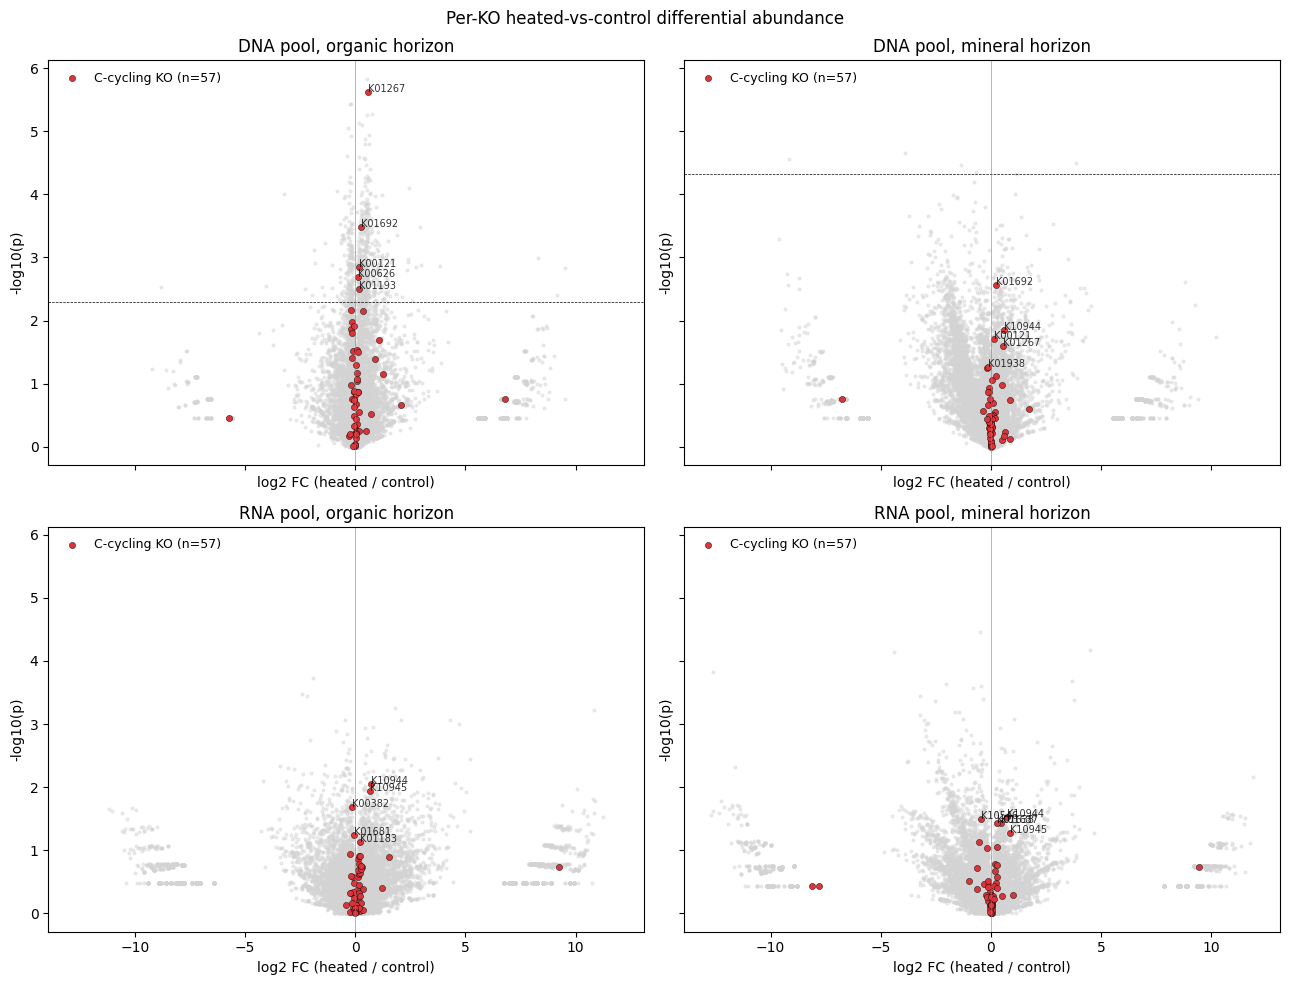

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/figures/05_c_cycling_volcano.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
panels = [
    ('DNA', 'organic', axes[0, 0]),
    ('DNA', 'mineral', axes[0, 1]),
    ('RNA', 'organic', axes[1, 0]),
    ('RNA', 'mineral', axes[1, 1]),
]
for pool, hz, ax in panels:
    sub = DA[(DA['pool'] == pool) & (DA['horizon'] == hz)].copy()
    sub['neglog10p'] = -np.log10(sub['p'].clip(lower=1e-12))
    sub['is_c'] = sub['ko'].isin(c_set)
    other = sub[~sub['is_c']]
    ccyc = sub[sub['is_c']]
    ax.scatter(other['log2_fc'], other['neglog10p'], s=4, color='lightgray', alpha=0.4, rasterized=True)
    ax.scatter(ccyc['log2_fc'], ccyc['neglog10p'], s=20, color='#d9343a', edgecolors='black',
                linewidths=0.3, label=f'C-cycling KO (n={len(ccyc)})')
    # 0.10 q-value threshold contour: find min p among rows with q<0.10
    if (sub['q'] < 0.10).any():
        pmax = sub.loc[sub['q'] < 0.10, 'p'].max()
        ax.axhline(-np.log10(pmax), color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.4)
    ax.set_title(f'{pool} pool, {hz} horizon')
    ax.set_xlabel('log2 FC (heated / control)')
    ax.set_ylabel('-log10(p)')
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    # Label top C-cycling hits
    top = ccyc.sort_values('p').head(5)
    for _, r in top.iterrows():
        ax.annotate(r['ko'], (r['log2_fc'], r['neglog10p']), fontsize=7, alpha=0.8)
plt.suptitle('Per-KO heated-vs-control differential abundance')
plt.tight_layout()
out = os.path.join(FIG_DIR, '05_c_cycling_volcano.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Wrote {out}')

## 5. H1 sensitivity check — direct samples only

In NB04, the paired DNA∩RNA subset confounded `horizon` with `incubated`. To get a clean H1 test, look at direct-sampled biosamples only (n=14 DNA mineral, n=11 RNA mineral; n=14 RNA organic direct). Compute per-pool PERMANOVA on the *direct* samples in each horizon and compare R² for treatment between DNA and RNA.

In [7]:
def permanova(D, groups, n_perm=4999, seed=42):
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    g = pd.Series(groups, dtype='category')
    levels = g.cat.categories
    a = len(levels)
    SS_T = (D ** 2).sum() / (2 * n)
    def ss_within(labels):
        s = 0.0
        for L in levels:
            idx = np.where(labels == L)[0]
            if len(idx) > 1:
                Dsub = D[np.ix_(idx, idx)]
                s += (Dsub ** 2).sum() / (2 * len(idx))
        return s
    SS_W = ss_within(g.values)
    SS_A = SS_T - SS_W
    if SS_W <= 0:
        return np.nan, np.nan, np.nan
    F = (SS_A / (a - 1)) / (SS_W / (n - a))
    R2 = SS_A / SS_T
    perm_F = np.empty(n_perm)
    labels_arr = np.asarray(g.values)
    for k in range(n_perm):
        perm = rng.permutation(labels_arr)
        SS_W_p = ss_within(perm)
        SS_A_p = SS_T - SS_W_p
        if SS_W_p > 0:
            perm_F[k] = (SS_A_p / (a - 1)) / (SS_W_p / (n - a))
        else:
            perm_F[k] = np.nan
    p = (np.sum(perm_F >= F) + 1) / (n_perm + 1)
    return F, p, R2

rows = []
# Direct mineral samples — DNA and RNA
for pool, M in [('DNA', dna_rab), ('RNA', rna_rab)]:
    samples = M.index.tolist()
    meta_sub = design_idx.loc[samples]
    # Only direct mineral OR direct organic (the latter only exists for RNA)
    for hz in ['mineral', 'organic']:
        idx_dir = meta_sub.index[(meta_sub['horizon'] == hz) & (~meta_sub['incubated'])]
        if len(idx_dir) < 6:
            rows.append({'pool': pool, 'horizon': hz, 'sample_set': 'direct',
                          'n': len(idx_dir), 'F': np.nan, 'R2': np.nan, 'p': np.nan,
                          'note': 'too few samples'})
            continue
        Msub = M.loc[idx_dir]
        D = squareform(pdist(Msub.values, metric='braycurtis'))
        treats = meta_sub.loc[idx_dir, 'treatment'].values
        F, p, R2 = permanova(D, treats)
        rows.append({'pool': pool, 'horizon': hz, 'sample_set': 'direct',
                      'n': len(idx_dir), 'F': F, 'R2': R2, 'p': p, 'note': ''})
h1_sens = pd.DataFrame(rows)
print('H1 sensitivity (direct samples only, per horizon):')
print(h1_sens.to_string(index=False))

H1 sensitivity (direct samples only, per horizon):
pool horizon sample_set  n        F       R2      p            note
 DNA mineral     direct 14 1.747537 0.127116 0.0810                
 DNA organic     direct  0      NaN      NaN    NaN too few samples
 RNA mineral     direct 11 1.154766 0.113717 0.2544                
 RNA organic     direct 14 1.329968 0.099773 0.1904                


## 6. Save outputs

In [8]:
DA.to_csv(os.path.join(DATA_DIR, '05_da_per_ko_per_pool_per_horizon.tsv.gz'),
          sep='\t', index=False, compression='gzip')
enrich.to_csv(os.path.join(DATA_DIR, '05_c_cycling_enrichment.tsv'), sep='\t', index=False)
h1_sens.to_csv(os.path.join(DATA_DIR, '05_h1_sensitivity_direct.tsv'), sep='\t', index=False)
print('Saved DA, enrichment, and H1 sensitivity tables to data/.')

Saved DA, enrichment, and H1 sensitivity tables to data/.


## 7. Summary

1. **C-cycling enrichment (H2)**: `05_c_cycling_enrichment.tsv` reports OR and one-sided Fisher p-value for the curated 60-KO list being enriched in heated-up hits, separately for DNA × organic, DNA × mineral, RNA × organic, RNA × mineral. Look at the OR values to judge effect size.
2. **Top hits by category**: tables above identify which CAZymes / TCA / etc. are leading the response.
3. **H1 sensitivity (direct samples)**: re-runs the PERMANOVA without the incubation confound. Compare DNA-vs-RNA R² for treatment in pure-direct-sample subsets.